In [1]:
from pathlib import Path
import pandas as pd
import torch
import matplotlib.pyplot as plt
import xarray as xr
import yaml
import geopandas as gpd
import numpy as np
import pickle
from neuralhydrology.evaluation.metrics import calculate_all_metrics
from neuralhydrology.evaluation.metrics import calculate_metrics
from neuralhydrology.evaluation.metrics import missed_peaks
import neuralhydrology
from scipy import stats
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools


from recession import sig_BaseflowRecessionK, util_DataCheck, util_RecessionSegments, util_MasterRecessionCurve

In [2]:
# ------------------- Paths -------------------
RUN_DIR = Path("../runs") #Uruguay
# RUN_DIR = Path("../extending_caravan/runs") #USA

# Ensemble metrics

In [3]:
# URUGUAY

run_pattern = "precip_prcp_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_seed_*"
# run_pattern = "precip_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_seed_*" 
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_gauge_mm_day_seed_*"
# run_pattern = "precip_prcp_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 
# run_pattern = "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 
# run_pattern = "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*" 

matched_paths = sorted(RUN_DIR.glob(f"{run_pattern}/validation/model_epoch030/validation_results.p"))
print(f"Found {len(matched_paths)} runs: {[p.parts[-4] for p in matched_paths]}")

Found 8 runs: ['precip_prcp_mm_day_seed_111_2202_184533', 'precip_prcp_mm_day_seed_222_2202_185112', 'precip_prcp_mm_day_seed_333_2202_185649', 'precip_prcp_mm_day_seed_444_2202_190226', 'precip_prcp_mm_day_seed_555_2302_064058', 'precip_prcp_mm_day_seed_666_2302_064647', 'precip_prcp_mm_day_seed_777_2302_065235', 'precip_prcp_mm_day_seed_888_2302_065823']


In [4]:
# Load all runs
all_runs_data = []
for file_path in matched_paths:
    with open(file_path, "rb") as f:
        all_runs_data.append(pickle.load(f))

# Average the simulated flows across seeds, per basin
ensemble_data = {}

for basin_id in all_runs_data[0].keys():
    # Stack simulated flows from all seeds: shape (n_seeds, n_timesteps, time_step)
    sims = np.stack([
        run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values #['QObs(mm/d)_sim'].values 
        for run in all_runs_data
    ], axis=0)
    
    mean_sim = np.mean(sims, axis=0)  # Average across seeds
    mean_sim[mean_sim < 0] = np.nan # remove negative values (because then I can't fit the log(Q))
    
    # Copy structure from first run, replace sim with ensemble mean
    xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
    xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim #['QObs(mm/d)_sim'].values[:] = mean_sim #
    
    ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}

ensemble_data

{'CAMELS_UY_10': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.09307 0.1167 ... 0.09939
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.5385 0.4731 ... 0.4858}},
 'CAMELS_UY_11': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
     * time_step      (time_step) int64 8B 0
   Data variables:
       QObs_mm_d_obs  (date, time_step) float32 15kB 0.263 0.2622 ... 0.4166 0.4053
       QObs_mm_d_sim  (date, time_step) float32 15kB 0.6404 0.5621 ... 0.5564}},
 'CAMELS_UY_15': {'1D': {'xr': <xarray.Dataset> Size: 58kB
   Dimensions:        (date: 3652, time_step: 1)
   Coordinates:
     * date           (d

In [5]:
ds = ensemble_data['CAMELS_UY_6']['1D']['xr']
ds

<xarray.Dataset> Size: 58kB
Dimensions:        (date: 3652, time_step: 1)
Coordinates:
  * date           (date) datetime64[ns] 29kB 1989-10-01 ... 1999-09-30
  * time_step      (time_step) int64 8B 0
Data variables:
    QObs_mm_d_obs  (date, time_step) float32 15kB 0.2257 0.2025 ... 0.2723
    QObs_mm_d_sim  (date, time_step) float32 15kB 0.628 0.5523 ... 0.4464 0.4742

In [6]:
basin = "CAMELS_UY_6"


--- Observed ---
BaseflowRecessionK (K): 0.1224
error_flag:             1
error_str:              Warning: Ignoring NaNs in streamflow data. 
-> Shallow subsurface flow dominated, fast-draining system

--- Simulated ---
BaseflowRecessionK (K): 0.0866
error_flag:             0
error_str:              
-> Shallow subsurface flow dominated, fast-draining system


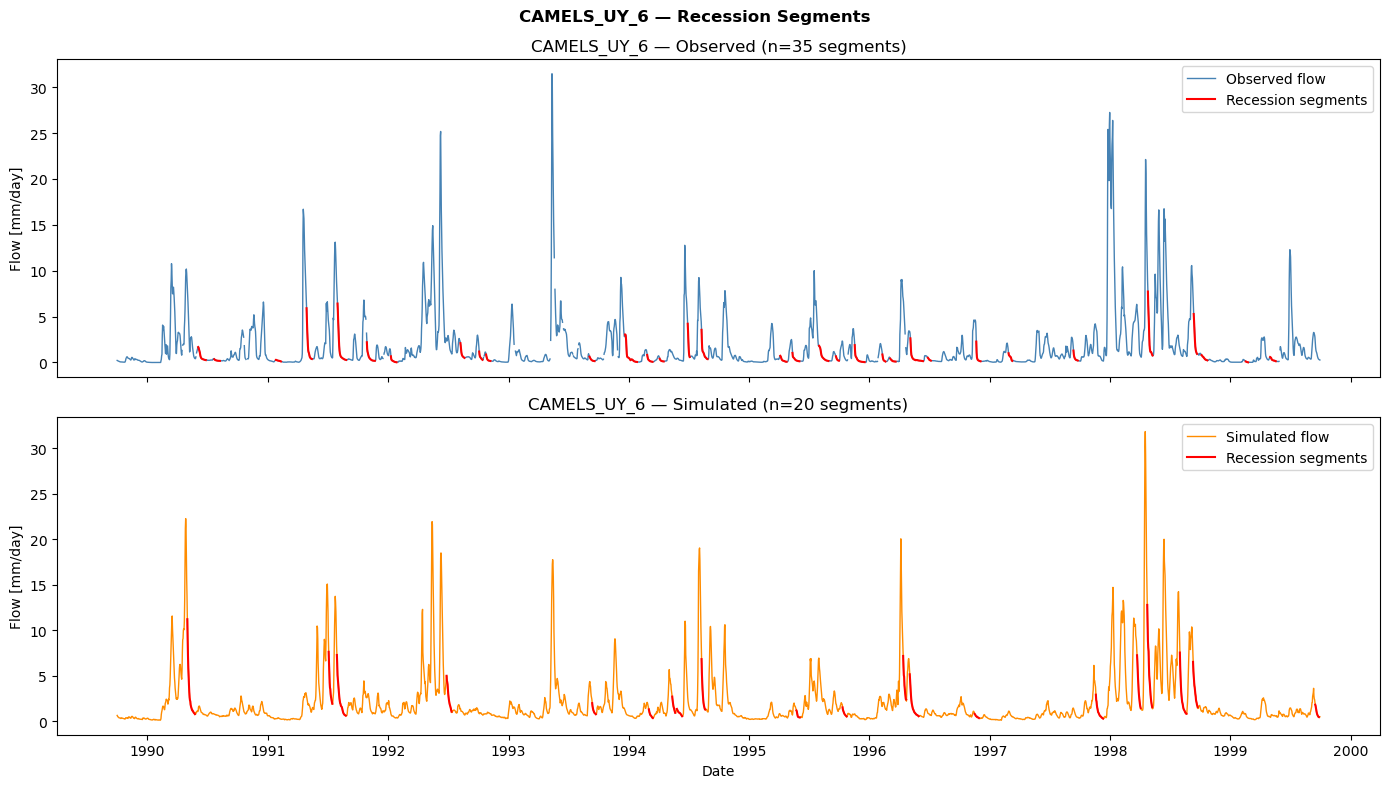

In [7]:
# for basin in all_runs_data[0].keys():
ds = ensemble_data[basin]['1D']['xr']
t = ds['date'].values

for var, label in [('QObs_mm_d_obs', 'Observed'), ('QObs_mm_d_sim', 'Simulated')]:
    Q = ds[var].values.squeeze().astype(float)
    K, error_flag, error_str = sig_BaseflowRecessionK(Q, t)
    
    print(f"\n--- {label} ---")
    print(f"BaseflowRecessionK (K): {K:.4f}")
    print(f"error_flag:             {error_flag}")
    print(f"error_str:              {error_str}")
    
    if not np.isnan(K):
        if K < 0.065:
            print("-> Groundwater-dominated, slow-draining system")
        else:
            print("-> Shallow subsurface flow dominated, fast-draining system")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (var, label, color) in zip(axes, [
    ('QObs_mm_d_obs', 'Observed',  'steelblue'),
    ('QObs_mm_d_sim', 'Simulated', 'darkorange')
]):
    Q = ds[var].values.squeeze().astype(float)

    # DataCheck and recession segments
    _, _, _, t_clean = util_DataCheck(Q, t)
    flow_section, _, _ = util_RecessionSegments(
        Q, t_clean,
        recession_length=15,
        start_of_recession='baseflow',
        filter_par=0.925
    )

    # Full streamflow
    ax.plot(t_clean, Q, color=color, linewidth=1, label=f'{label} flow')

    # Recession segments
    for i, (start, end) in enumerate(flow_section):
        ax.plot(t_clean[start:end+1], Q[start:end+1],
                color='red', linewidth=1.5,
                label='Recession segments' if i == 0 else None)

    ax.set_ylabel('Flow [mm/day]')
    ax.set_title(f'{basin} — {label} (n={len(flow_section)} segments)')
    ax.legend()

axes[-1].set_xlabel('Date')
plt.suptitle(f'{basin} — Recession Segments', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# # After computing MRC
# MRC, lags, seg_indices, segments_aligned = util_MasterRecessionCurve(
#     Q, flow_section, fit_method='nonparametric_analytic', match_method='log'
# )

# fig, ax = plt.subplots(figsize=(7, 5))
# ax.set_yscale('log')

# # Plot each recession segment shifted by its lag
# for i, seg in enumerate(segments_aligned):
#     t_seg = np.arange(len(seg)) + lags[i]  # shift by lag
#     ax.plot(t_seg, seg, color='steelblue', alpha=0.4, linewidth=1)

# # Plot fitted MRC
# mrc_t = MRC[:, 0]
# mrc_q = MRC[:, 1]
# valid = mrc_q > 0
# A = np.column_stack([np.ones(valid.sum()), mrc_t[valid]])
# mdl, _, _, _ = np.linalg.lstsq(A, np.log(mrc_q[valid]), rcond=None)
# K = -mdl[1]
# t_fit = np.linspace(mrc_t.min(), mrc_t.max(), 200)
# ax.plot(t_fit, np.exp(mdl[0] + mdl[1] * t_fit), 'r-', linewidth=2,
#         label=f'Fitted curve (K={K:.4f})')

# ax.set_xlabel('Relative time [days]')
# ax.set_ylabel('Flow [mm/day]')
# ax.legend()
# plt.tight_layout()
# plt.show()

In [16]:
x_fit_limits = {"CAMELS_UY_10": (10,30),
                "CAMELS_UY_11": (10,30),
                "CAMELS_UY_2": (5,15),
                "CAMELS_UY_3": (5,20),
                "CAMELS_UY_5": (10,25),
                "CAMELS_UY_6": (10,25),
                "CAMELS_UY_7": (5,20),
                "CAMELS_UY_8": (15,25),
                "CAMELS_UY_9": (10,30)
                }

/tmp/ipykernel_10449/2518445059.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


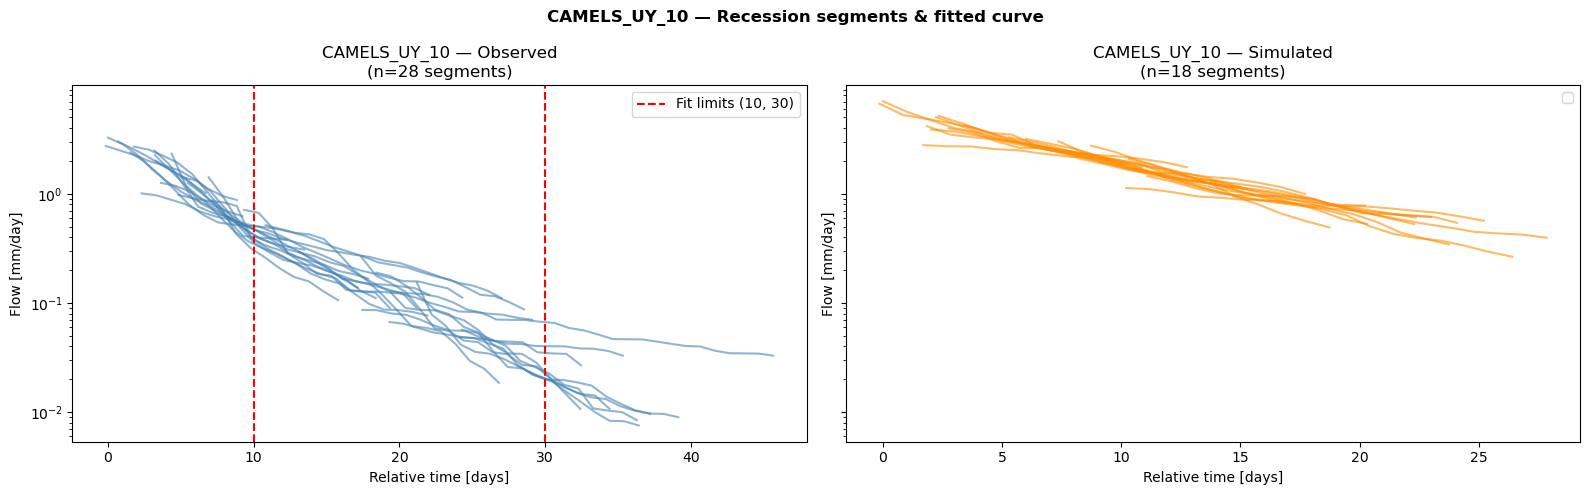

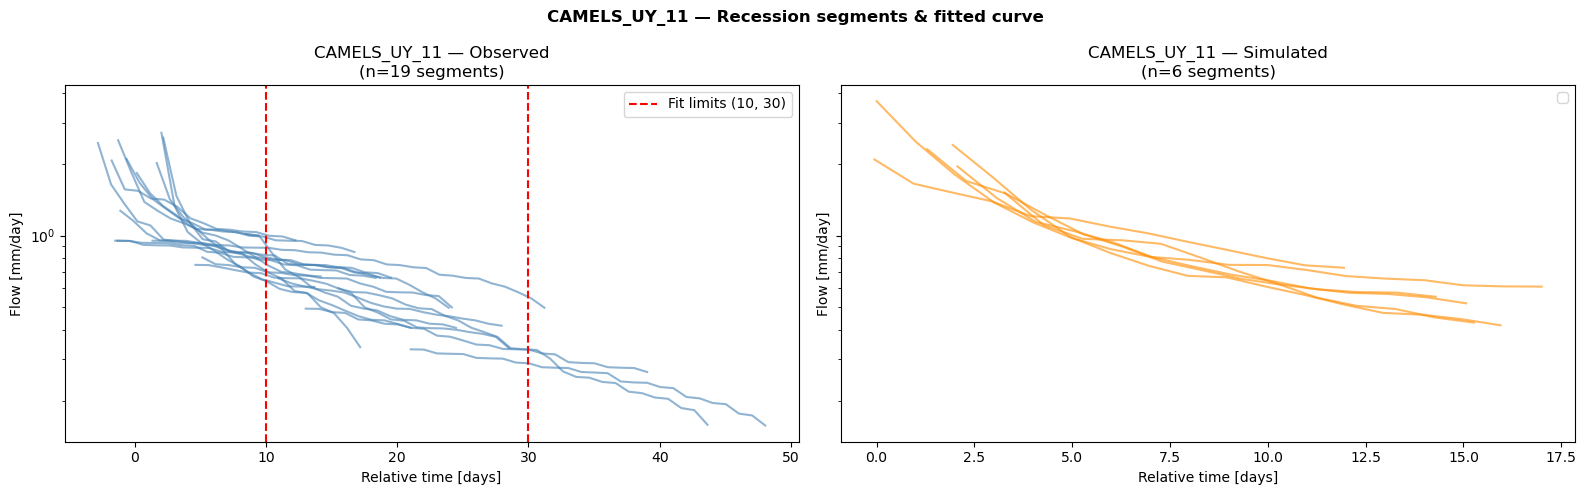

Skipping CAMELS_UY_15 (QObs_mm_d_sim): no recession segments found
Skipping CAMELS_UY_16 (QObs_mm_d_sim): no recession segments found


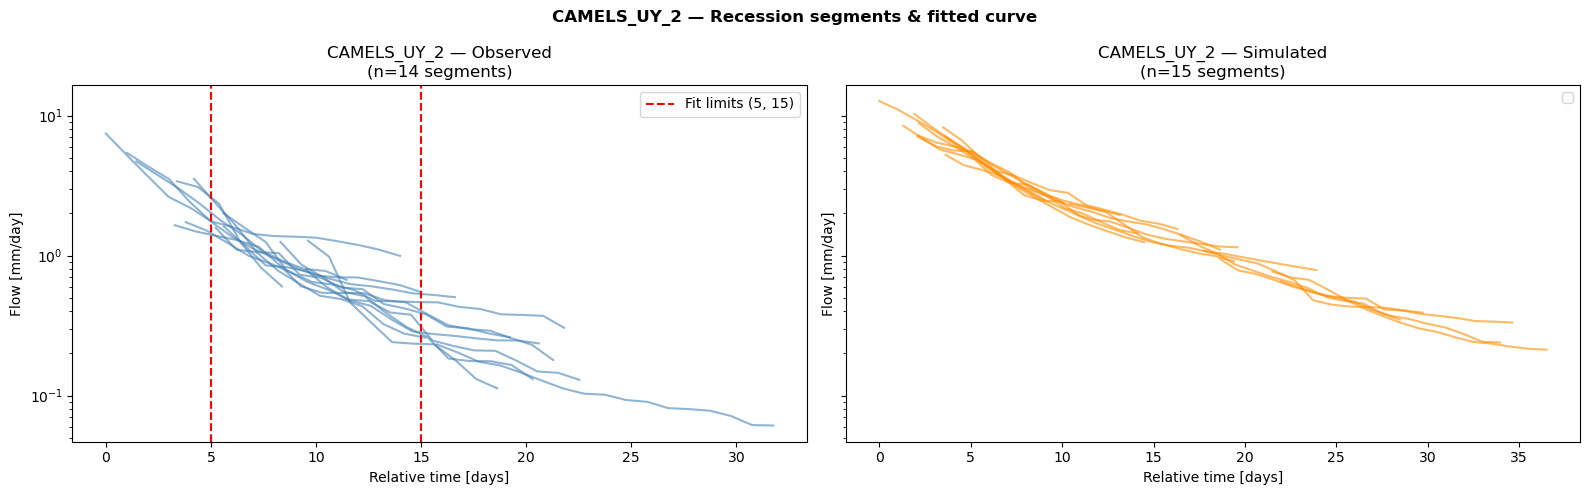

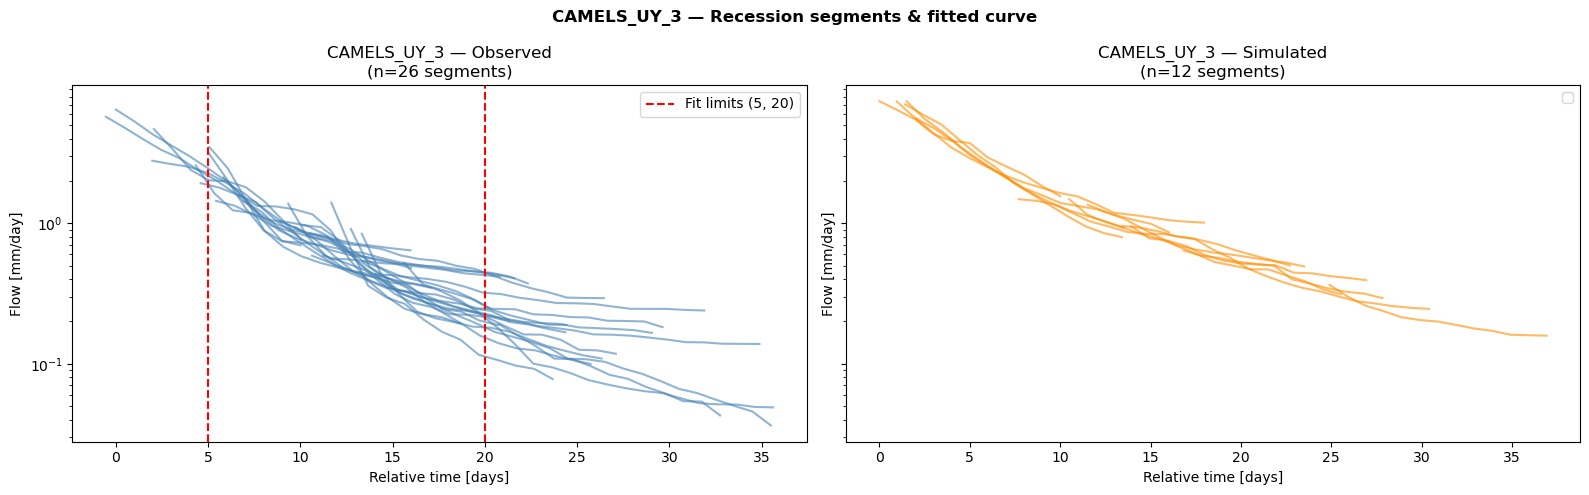

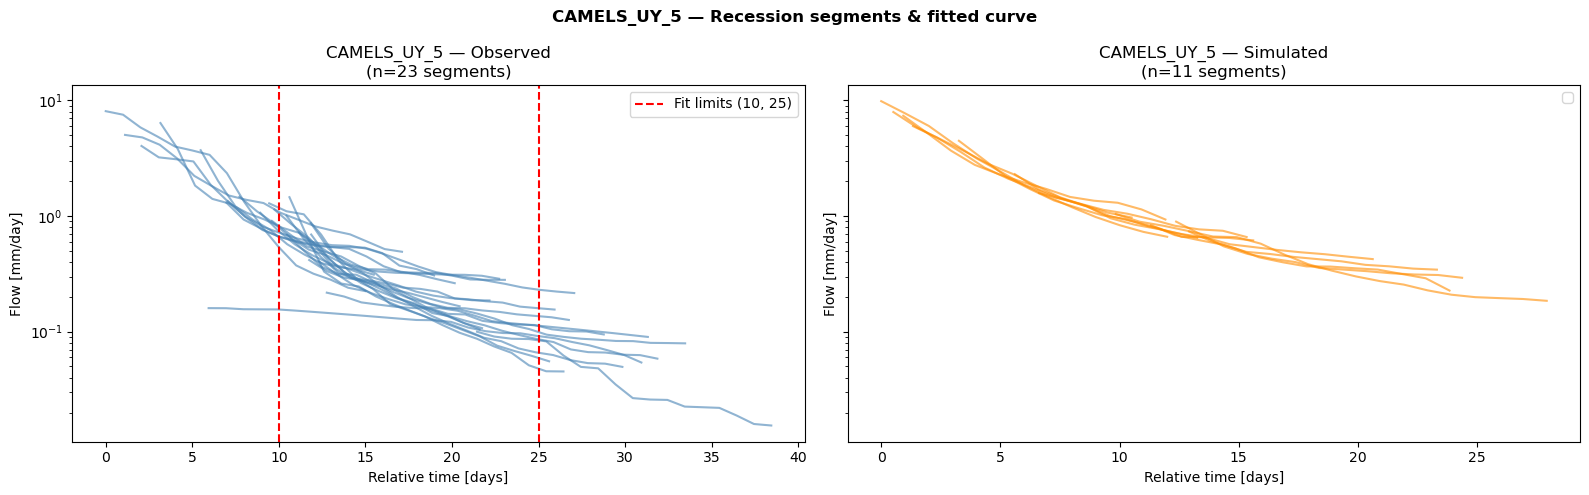

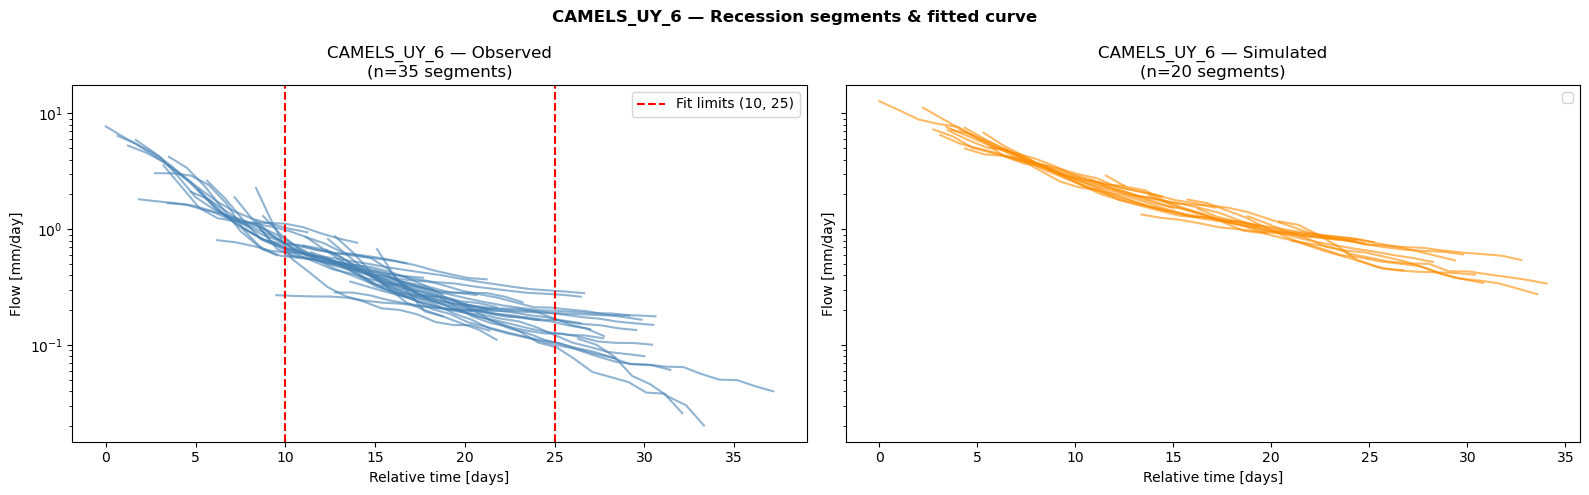

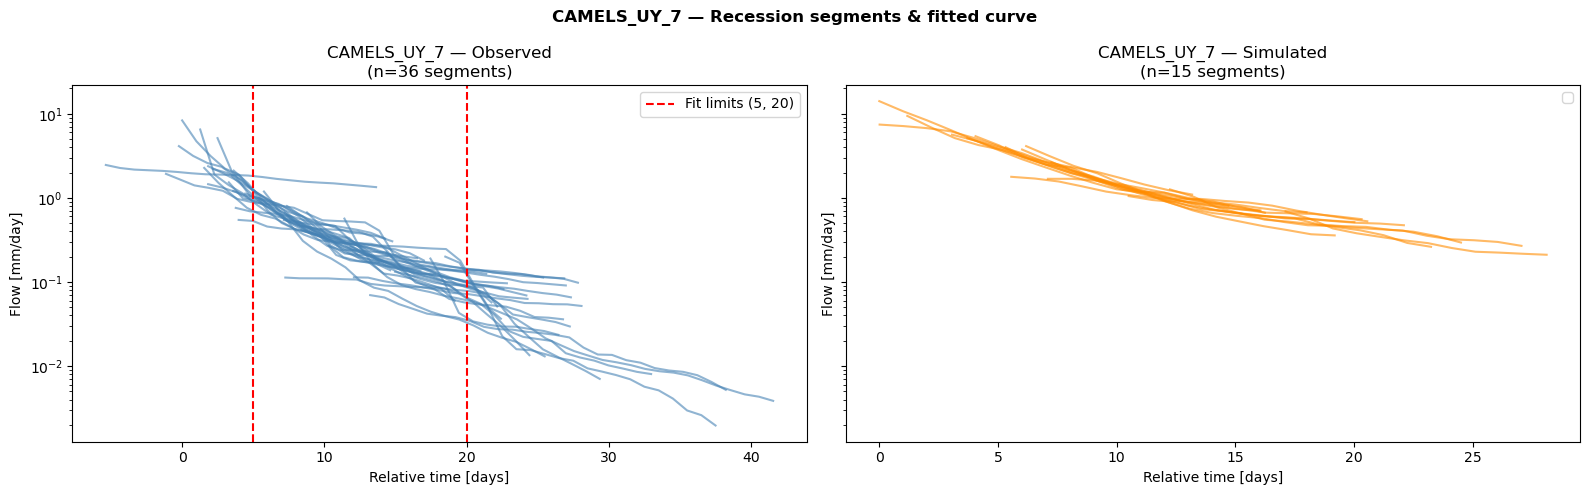

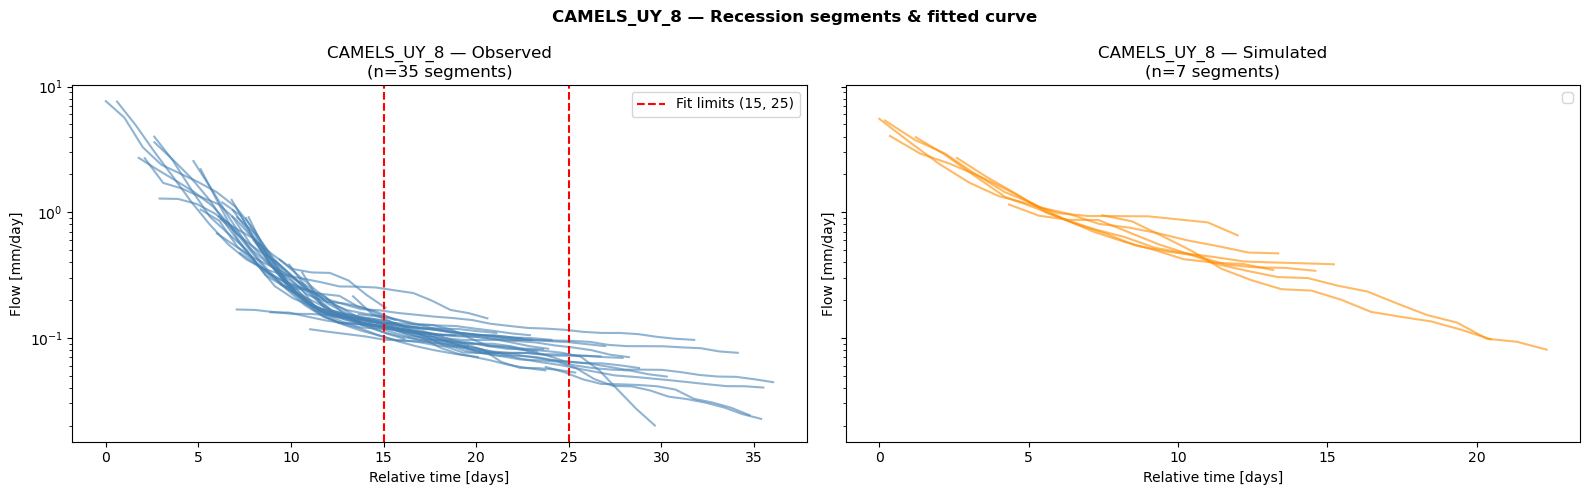

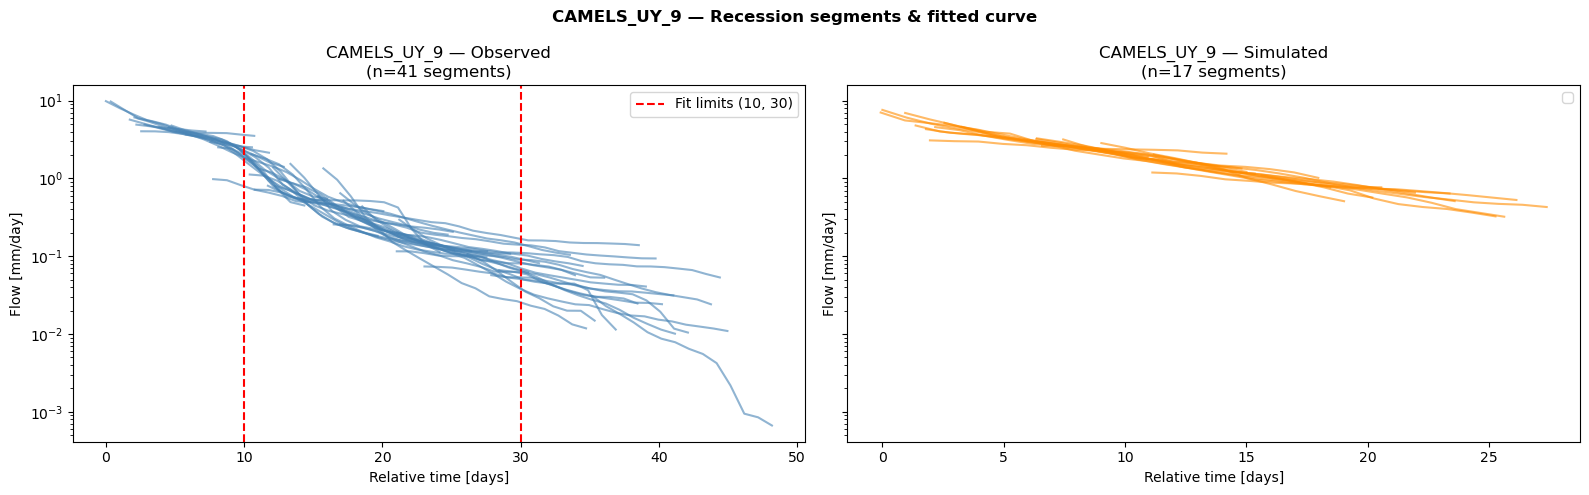

In [17]:
for basin in all_runs_data[0].keys():
    ds = ensemble_data[basin]['1D']['xr']
    t = ds['date'].values
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    skip = False  # flag to track if any var fails

    for ax, (var, label, color) in zip(axes, [
        ('QObs_mm_d_obs', 'Observed',  'steelblue'),
        ('QObs_mm_d_sim', 'Simulated', 'darkorange')
    ]):
        Q = ds[var].values.squeeze().astype(float)

        _, _, _, t_clean = util_DataCheck(Q, t)
        flow_section, _, _ = util_RecessionSegments(
            Q, t_clean,
            recession_length=15,
            n_start=1,
            start_of_recession='baseflow',
            filter_par=0.925
        )

        if len(flow_section) == 0:
            print(f"Skipping {basin} ({var}): no recession segments found")
            skip = True
            break

        MRC, lags, seg_indices, segments_aligned = util_MasterRecessionCurve(
            Q, flow_section, match_method='log'
        )

        for i, seg in enumerate(segments_aligned):
            t_seg = np.arange(1, len(seg) + 1) + lags[i]
            ax.plot(t_seg, seg, color=color, alpha=0.6, linewidth=1.5)

        if var == 'QObs_mm_d_obs' and basin in x_fit_limits:
            x_lo, x_hi = x_fit_limits[basin]
            ax.axvline(x_lo, color='red', linestyle='--', linewidth=1.5, label=f'Fit limits ({x_lo}, {x_hi})')
            ax.axvline(x_hi, color='red', linestyle='--', linewidth=1.5)

        ax.set_yscale('log')
        ax.set_xlabel('Relative time [days]')
        ax.set_ylabel('Flow [mm/day]')
        ax.set_title(f'{basin} — {label}\n(n={len(flow_section)} segments)')
        ax.legend()

    if skip:
        plt.close()  # don't show the empty figure
        continue

    plt.suptitle(f'{basin} — Recession segments & fitted curve', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [11]:
# for basin in all_runs_data[0].keys():

#     ds = ensemble_data[basin]['1D']['xr']
#     t = ds['date'].values

#     fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

#     for ax, (var, label, color) in zip(axes, [
#         ('QObs_mm_d_obs', 'Observed',  'steelblue'),
#         ('QObs_mm_d_sim', 'Simulated', 'darkorange')
#     ]):
#         Q = ds[var].values.squeeze().astype(float)

#         # DataCheck and recession segments
#         _, _, _, t_clean = util_DataCheck(Q, t)
#         flow_section, _, _ = util_RecessionSegments(
#             Q, t_clean,
#             recession_length=15,
#             n_start=1,
#             start_of_recession='baseflow',
#             filter_par=0.925
#         )

#         # Build MRC — unpack all 4 return values
#         MRC, lags, seg_indices, segments_aligned = util_MasterRecessionCurve(
#             Q, flow_section, match_method='log'
#         )

#         # Plot individual segments shifted by their lag
#         for i, seg in enumerate(segments_aligned):
#             t_seg = np.arange(1, len(seg) + 1) + lags[i]  # 1-based + lag, matching MATLAB
#             ax.plot(t_seg, seg, color=color, alpha=0.3, linewidth=1)

#         # Fit log-linear: log(Q) = a + b*t  =>  K = -b
#         mrc_t = MRC[:, 0]
#         mrc_q = MRC[:, 1]

#         # valid = mrc_q > 0

#         fit_start_time = 15
#         fit_end_time = 25

#         valid = (mrc_q > 0) & (mrc_t >= fit_start_time) & (mrc_t <= fit_end_time)

#         A = np.column_stack([np.ones(valid.sum()), mrc_t[valid]])
#         mdl, _, _, _ = np.linalg.lstsq(A, np.log(mrc_q[valid]), rcond=None)
#         K = -mdl[1]

#         # Plot fitted curve
#         t_fit = np.linspace(mrc_t.min(), mrc_t.max(), 300)
#         q_fit = np.exp(mdl[0] + mdl[1] * t_fit)
#         ax.plot(t_fit, q_fit, color='red', linewidth=2.5,
#                 label=f'Fitted curve (K={K:.4f})')

#         ax.set_yscale('log')  # set per axis, not just the last one
#         ax.set_xlabel('Relative time [days]')
#         ax.set_ylabel('Flow [mm/day]')
#         ax.set_title(f'{basin} — {label}\n(n={len(flow_section)} segments)')
#         ax.legend()

#     plt.suptitle(f'{basin} — Recession segments & fitted curve', fontweight='bold')
#     plt.tight_layout()
#     plt.show()

In [ ]:
# Define all run patterns you want to compare
run_patterns = {
    "caravan":        "precip_prcp_mm_day_seed_*",
    "chirps":         "precip_prcp_chirps_mm_day_seed_*",
    "mswep":          "precip_prcp_mswep_mm_day_seed_*",
    "gauge":          "precip_prcp_gauge_mm_day_seed_*",
    "chirps+mswep":   "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_seed_*",
    "chirps+mswep+gauge": "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*",
    "caravan+chirps+mswep+gauge": "precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seed_*"
}

def load_ensemble(pattern):
    """Load and average across seeds for a given run pattern."""
    matched_paths = sorted(RUN_DIR.glob(f"{pattern}/validation/model_epoch030/validation_results.p"))
    if not matched_paths:
        return None
    
    all_runs_data = []
    for file_path in matched_paths:
        with open(file_path, "rb") as f:
            all_runs_data.append(pickle.load(f))
    
    ensemble_data = {}
    for basin_id in all_runs_data[0].keys():
        sims = np.stack([
            run[basin_id]['1D']['xr']['QObs_mm_d_sim'].values
            for run in all_runs_data
        ], axis=0)
        mean_sim = np.mean(sims, axis=0)
        mean_sim[mean_sim < 0] = np.nan

        xr_ensemble = all_runs_data[0][basin_id]['1D']['xr'].copy()
        xr_ensemble['QObs_mm_d_sim'].values[:] = mean_sim
        ensemble_data[basin_id] = {'1D': {'xr': xr_ensemble}}
    
    return ensemble_data

def compute_K(Q, t):
    """Safe wrapper around sig_BaseflowRecessionK."""
    K, error_flag, error_str = sig_BaseflowRecessionK(Q, t, n_start=1)
    return K  # returns nan if error

# ── Main loop ──────────────────────────────────────────────────────────────────
all_records = {}

# First pass: compute K_obs once per basin
print("Computing K_obs (observations)...")
first_pattern = next(iter(run_patterns.values()))
first_ensemble = load_ensemble(first_pattern)
for basin_id, basin_data in first_ensemble.items():
    ds = basin_data['1D']['xr']
    t = ds['date'].values
    Q_obs = ds['QObs_mm_d_obs'].values.squeeze().astype(float)
    all_records[basin_id] = {'K_obs': compute_K(Q_obs, t)}

# Second pass: compute K_sim for every pattern
for label, pattern in run_patterns.items():
    print(f"Processing pattern: {label} ...")
    ensemble = load_ensemble(pattern)
    
    if ensemble is None:
        print(f"  -> No runs found, skipping.")
        for basin_id in all_records:
            all_records[basin_id][f'K_{label}'] = np.nan
        continue
    
    for basin_id, basin_data in ensemble.items():
        ds = basin_data['1D']['xr']
        t = ds['date'].values
        Q_sim = ds['QObs_mm_d_sim'].values.squeeze().astype(float)
        all_records[basin_id][f'K_{label}'] = compute_K(Q_sim, t)

# ── Build DataFrame ────────────────────────────────────────────────────────────
df_K = pd.DataFrame.from_dict(all_records, orient='index')
df_K.index.name = 'basin_id'
col_order = ['K_obs'] + [f'K_{label}' for label in run_patterns]
df_K = df_K[col_order]

pd.options.display.float_format = '{:.4f}'.format
df_K

Computing K_obs (observations)...


Processing pattern: caravan ...
Processing pattern: chirps ...
Processing pattern: mswep ...
Processing pattern: gauge ...
Processing pattern: chirps+mswep ...
Processing pattern: chirps+mswep+gauge ...
Processing pattern: caravan+chirps+mswep+gauge ...


,K_obs,K_caravan,K_chirps,K_mswep,K_gauge,K_chirps+mswep,K_chirps+mswep+gauge,K_caravan+chirps+mswep+gauge
basin_id,,,,,,,,
CAMELS_UY_10,0.1438,0.1218,0.1213,0.1308,0.1061,0.1192,0.1023,0.1435
CAMELS_UY_11,0.0663,0.0486,0.0528,0.0702,0.0753,0.0444,0.0686,0.0736
CAMELS_UY_15,0.0587,NaN,0.1660,NaN,NaN,0.0434,NaN,0.0562
CAMELS_UY_16,0.1878,NaN,NaN,NaN,NaN,NaN,0.2773,0.1063
CAMELS_UY_2,0.1509,0.1048,0.1291,0.1342,0.1116,0.1282,0.1039,0.1575
CAMELS_UY_3,0.1494,0.0938,0.1623,0.1427,0.1098,0.1217,0.1290,0.1455
CAMELS_UY_5,0.1339,0.1014,0.2413,0.1661,0.1499,0.1495,0.1528,0.2489
CAMELS_UY_6,0.1224,0.0866,0.1114,0.1221,0.0790,0.1099,0.0872,0.1165
CAMELS_UY_7,0.2511,0.1049,0.1268,0.2717,0.0952,0.0950,0.1003,0.1686


In [ ]:
# df_K.mean()


In [ ]:
def shapiro_test(df, metric_name):
    print(f"\nShapiro-Wilk — {metric_name}")
    print("=" * 45)
    for model in df.columns:
        col = df[model].dropna()
        stat, p = stats.shapiro(col)
        normal = "✅ Normal" if p > 0.05 else "❌ Non-normal"
        print(f"{model:35s}  W={stat:.4f}  p={p:.4f}  {normal}")

# Rename columns to clean model names
k_df = df_K.rename(columns={
    'K_obs':                          'obs',
    'K_caravan':                      'caravan',
    'K_chirps':                       'chirps',
    'K_mswep':                        'mswep',
    'K_gauge':                        'gauge',
    'K_chirps+mswep':                 'chirps+mswep',
    'K_chirps+mswep+gauge':           'chirps+mswep+gauge',
    'K_caravan+chirps+mswep+gauge':   'caravan+chirps+mswep+gauge'
})

shapiro_test(k_df, 'K')


Shapiro-Wilk — K
obs                                  W=0.9380  p=0.4974  ✅ Normal
caravan                              W=0.9477  p=0.6645  ✅ Normal
chirps                               W=0.8948  p=0.1918  ✅ Normal
mswep                                W=0.8263  p=0.0405  ❌ Non-normal
gauge                                W=0.8953  p=0.2260  ✅ Normal
chirps+mswep                         W=0.8771  p=0.1209  ✅ Normal
chirps+mswep+gauge                   W=0.7947  p=0.0125  ❌ Non-normal
caravan+chirps+mswep+gauge           W=0.7166  p=0.0008  ❌ Non-normal


In [ ]:
def friedman_test(df, metric_name):
    data = [df[col].values for col in df.columns]
    stat, p = friedmanchisquare(*data)
    
    # Kendall's W effect size
    k = len(df.columns)  # number of models
    n = len(df)          # number of catchments
    W = stat / (n * (k - 1))
    
    # Effect size interpretation
    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"
    
    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²        = {stat:.4f}")
    print(f"  p-value   = {p:.4f}")
    print(f"  Kendall W = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'❌ Significant difference between models (p < 0.05)' if p < 0.05 else '✅ No significant difference between models (p >= 0.05)'}")
    
    return stat, p, W

In [ ]:
results = {}

k_df_clean = k_df.dropna() # Drop rows with ANY NaN so all models are compared on the same basins
stat, p, W = friedman_test(k_df_clean, 'K')
results['K'] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — K
  χ²        = 30.7037
  p-value   = 0.0001
  Kendall W = 0.4874 (moderate effect)
  n catchments = 9, k models = 8

  ❌ Significant difference between models (p < 0.05)


In [ ]:
def posthoc_wilcoxon(df, metric_name, friedman_p):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs = list(itertools.combinations(models, 2))
    
    rows = []
    for m1, m2 in pairs:
        # Uses paired differences — respects your blocked design
        stat, p_raw = wilcoxon(df[m1].values, df[m2].values)
        rows.append({'model_1': m1, 'model_2': m2, 'p_raw': p_raw})
    
    results_df = pd.DataFrame(rows)
    
    # Bonferroni correction
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05
    
    print(f"\n{'='*65}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}")
    print(f"{'='*65}")
    for _, row in results_df.iterrows():
        sig = "❌ different" if row['significant'] else "✅ similar"
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"p_raw={row['p_raw']:.4f}  p_adj={row['p_corrected']:.4f}  {sig}")
    
    return results_df

In [ ]:
posthoc_results = {}
result = posthoc_wilcoxon(k_df_clean, 'K', p)
if result is not None:
    posthoc_results['K'] = result


  Wilcoxon signed-rank + Bonferroni — K
  obs                  vs caravan               p_raw=0.0977  p_adj=1.0000  ✅ similar
  obs                  vs chirps                p_raw=0.6523  p_adj=1.0000  ✅ similar
  obs                  vs mswep                 p_raw=0.8203  p_adj=1.0000  ✅ similar
  obs                  vs gauge                 p_raw=0.2031  p_adj=1.0000  ✅ similar
  obs                  vs chirps+mswep          p_raw=0.0391  p_adj=1.0000  ✅ similar
  obs                  vs chirps+mswep+gauge    p_raw=0.2031  p_adj=1.0000  ✅ similar
  obs                  vs caravan+chirps+mswep+gauge  p_raw=0.7344  p_adj=1.0000  ✅ similar
  caravan              vs chirps                p_raw=0.0195  p_adj=0.5469  ✅ similar
  caravan              vs mswep                 p_raw=0.0039  p_adj=0.1094  ✅ similar
  caravan              vs gauge                 p_raw=0.4961  p_adj=1.0000  ✅ similar
  caravan              vs chirps+mswep          p_raw=0.4961  p_adj=1.0000  ✅ similar
  carav